In [1]:
import pandas as pd

In [70]:
# load dataset
df1 = pd.read_csv('../datos/datos_termografia_procesados_primeras_fotos.csv')
# null values
df1.isnull().sum()

numero de muestra                       0
nombre                                  0
cedula                                  0
sexo                                    0
ocupacion                               0
edad                                    0
temperatura ambiente                    0
temperatura basal                       0
diagnosticado con ttm                   0
imagen: temperatura maxima derecha      0
imagen: temperatura minima derecha      0
imagen: temperatura media derecha       0
r2: temperatura maxima derecha          0
r2: temperatura minima derecha          0
r2: temperatura media derecha           0
r3: temperatura maxima derecha          0
r3: temperatura minima derecha          0
r3: temperatura media derecha           0
r4: temperatura maxima derecha          0
r4: temperatura minima derecha          0
r4: temperatura media derecha           0
r1: temperatura maxima derecha          0
r1: temperatura minima derecha          0
r1: temperatura media derecha     

In [62]:
# load dataset
df2 = pd.read_csv('../datos/datos_termografia_procesados_segundas_fotos.csv')
# null values
df2.isnull().sum()

numero de muestra                        0
nombre                                   0
cedula                                   0
sexo                                     0
ocupacion                                0
edad                                     0
temperatura ambiente                     0
temperatura basal                        0
diagnosticado con ttm                    0
imagen: temperatura maxima derecha       0
imagen: temperatura minima derecha       0
imagen: temperatura media derecha        0
p1 derecha                              21
p2 derecha                              25
r2: temperatura maxima derecha           0
r2: temperatura minima derecha           0
r2: temperatura media derecha            0
r3: temperatura maxima derecha           0
r3: temperatura minima derecha           0
r3: temperatura media derecha            0
r4: temperatura maxima derecha           0
r4: temperatura minima derecha           0
r4: temperatura media derecha            0
r1: tempera

In [33]:

def mostrar_nulos(df, columna):
    """
    Muestra las filas del DataFrame que tienen valores nulos en una columna específica.
    """
    if columna not in df.columns:
        print(f"Error: La columna '{columna}' no existe en el DataFrame.")
        return None

    nulos = df[df[columna].isna()]

    if nulos.empty:
        print(f"No se encontraron valores nulos en la columna '{columna}'.")
    else:
        print(f"Se encontraron {len(nulos)} registros con valores nulos en '{columna}':")
        print(nulos)

    return nulos


In [110]:
df8 = pd.read_csv('../datos/datos_finales_termografia_procesados_segundas_fotos.csv')
# null values
df8.isnull().sum()

numero de muestra          0
nombre                     0
cedula                     0
sexo                       0
ocupacion                  0
                          ..
temporal_derecho_r1p2      0
temporal_derecho_r1p7      0
temporal_izquierdo_r1p1    0
temporal_izquierdo_r1p2    0
temporal_izquierdo_r1p3    0
Length: 107, dtype: int64

In [69]:
nulos = mostrar_nulos(df1, 'imagen: temperatura minima izquierda')
nulos

No se encontraron valores nulos en la columna 'imagen: temperatura minima izquierda'.


,numero de muestra,nombre,cedula,sexo,ocupacion,edad,temperatura ambiente,temperatura basal,diagnosticado con ttm,imagen: temperatura maxima derecha,...,r4: temperatura minima izquierda,r4: temperatura media izquierda,r1: temperatura maxima izquierda,r1: temperatura minima izquierda,r1: temperatura media izquierda,delta_t_r1,delta_t_r2,delta_t_r3,delta_t_r4,delta_t_global_media


In [67]:
df1.iloc[32]

numero de muestra                                 33.0
nombre                                  BeatrizPacheco
cedula                                      14934351.0
sexo                                          Femenino
ocupacion                               Administradora
edad                                              44.0
temperatura ambiente                              20.3
temperatura basal                                 36.4
diagnosticado con ttm                               Si
imagen: temperatura maxima derecha                34.8
imagen: temperatura minima derecha                17.8
imagen: temperatura media derecha                 24.2
r2: temperatura maxima derecha                    33.0
r2: temperatura minima derecha                    24.4
r2: temperatura media derecha                     30.6
r3: temperatura maxima derecha                    34.8
r3: temperatura minima derecha                    23.8
r3: temperatura media derecha                     31.6
r4: temper

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generar_graficos_contraste(df):
    """
    Crea visualizaciones para comparar la asimetría térmica (Delta T)
    entre el grupo con TTM y el grupo Sano.
    """
    # 1. Preparar los datos: "Derretir" el dataframe para Seaborn
    # Buscamos la columna de diagnóstico de forma robusta (insensible a mayúsculas/minúsculas)
    col_diagnostico = next((col for col in df.columns if 'diagnosticado con ttm' in col.lower()), None)
    
    if not col_diagnostico:
        print("Error: No se encontró la columna de diagnóstico ('diagnosticado con ttm')")
        return

    # Buscamos las columnas que contienen 'delta_t'
    columnas_delta = [col for col in df.columns if 'delta_t' in col.lower()]
    
    if not columnas_delta:
        print("Error: No se encontraron columnas que contengan 'delta_t'")
        return

    # Creamos una versión "larga" del dataframe para facilitar el graficado
    df_long = pd.melt(df,
                      id_vars=[col_diagnostico],
                      value_vars=columnas_delta,
                      var_name='ROI',
                      value_name='Asimetría_Termica')

    # 2. Configuración estética
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # 3. Crear el Boxplot + Swarmplot (para ver los puntos individuales)
    ax = sns.boxplot(x='ROI', y='Asimetría_Termica', hue=col_diagnostico,
                     data=df_long, palette='RdBu_r', showfliers=False)

    # Añadimos los puntos individuales para ver la distribución real (útil en muestras pequeñas)
    sns.stripplot(x='ROI', y='Asimetría_Termica', hue=col_diagnostico,
                  data=df_long, dodge=True, alpha=0.5, palette='dark:.3', legend=False)

    # 4. Personalización del gráfico
    plt.title(r'Comparativa de Asimetría Térmica ($\Delta T$) por ROI: TTM vs Sano', fontsize=15)
    plt.ylabel('Diferencia de Temperatura (°C)', fontsize=12)
    plt.xlabel('Región de Interés (ROI)', fontsize=12)
    plt.axhline(y=0.4, color='red', linestyle='--', label='Umbral Clínico Sugerido (0.4°C)')
    plt.legend(title='¿Diagnóstico TTM?')

    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
# generar_graficos_contraste(df_maestro)

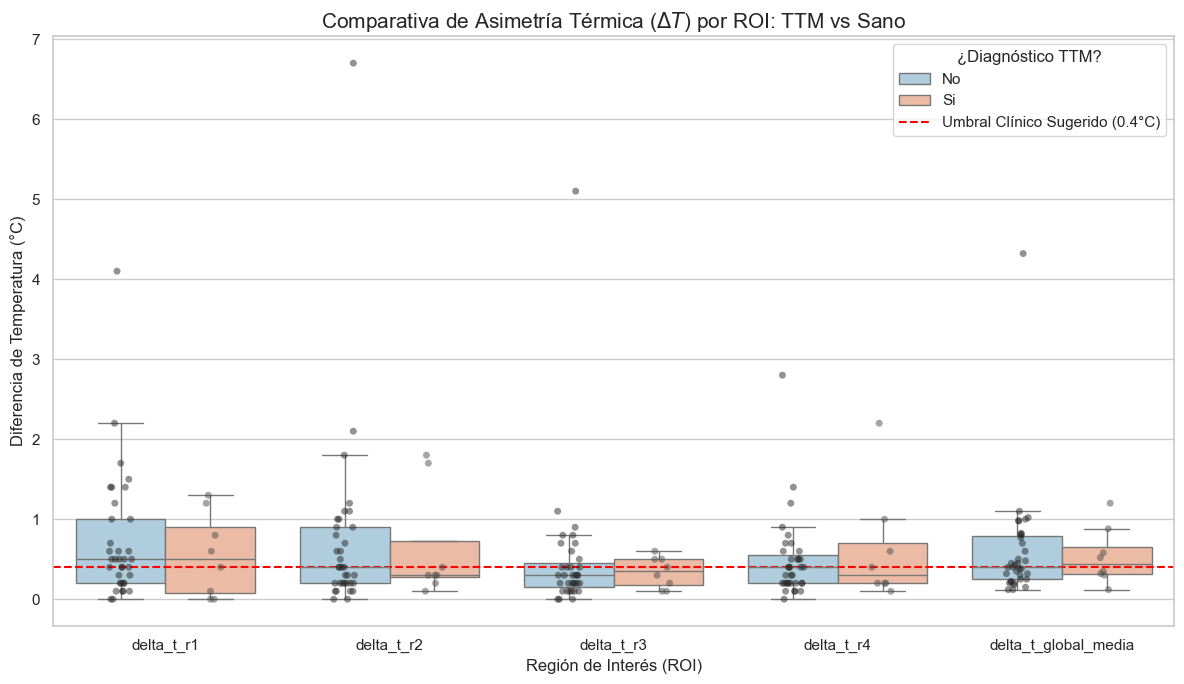

In [83]:
generar_graficos_contraste(df1)

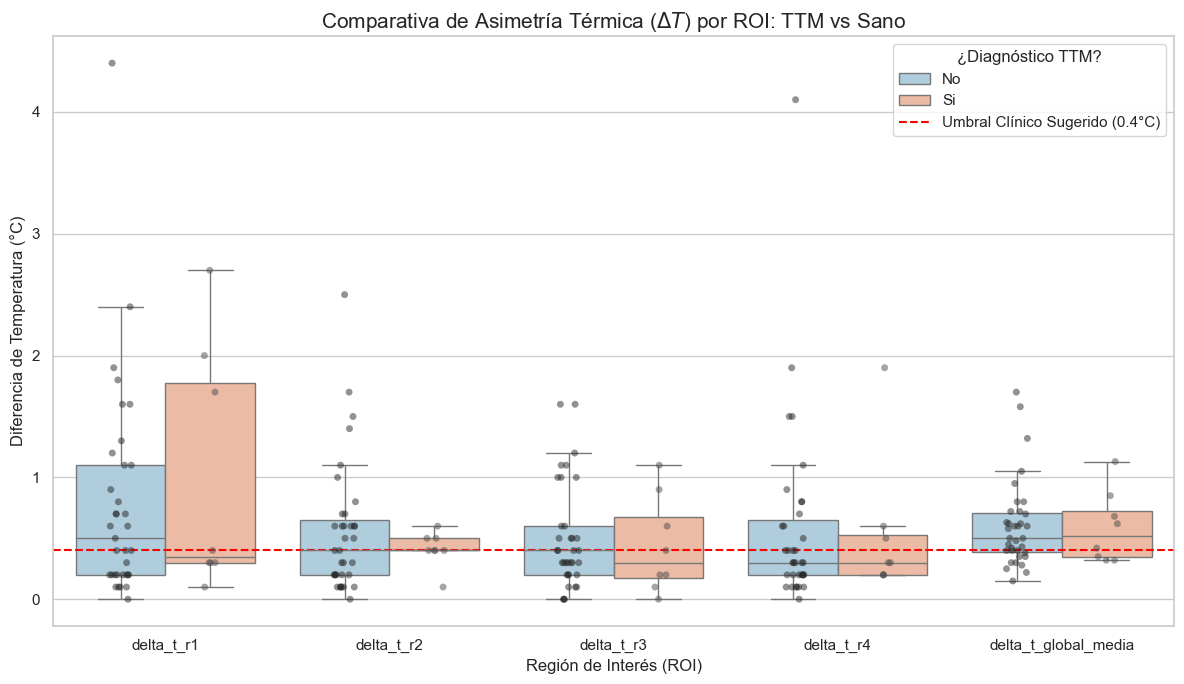

In [84]:
generar_graficos_contraste(df2)

In [78]:
df1.columns

Index(['numero de muestra', 'nombre', 'cedula', 'sexo', 'ocupacion', 'edad',
       'temperatura ambiente', 'temperatura basal', 'diagnosticado con ttm',
       'imagen: temperatura maxima derecha',
       'imagen: temperatura minima derecha',
       'imagen: temperatura media derecha', 'r2: temperatura maxima derecha',
       'r2: temperatura minima derecha', 'r2: temperatura media derecha',
       'r3: temperatura maxima derecha', 'r3: temperatura minima derecha',
       'r3: temperatura media derecha', 'r4: temperatura maxima derecha',
       'r4: temperatura minima derecha', 'r4: temperatura media derecha',
       'r1: temperatura maxima derecha', 'r1: temperatura minima derecha',
       'r1: temperatura media derecha', 'imagen: temperatura maxima izquierda',
       'imagen: temperatura minima izquierda',
       'imagen: temperatura media izquierda',
       'r2: temperatura maxima izquierda', 'r2: temperatura minima izquierda',
       'r2: temperatura media izquierda', 'r3: tempera

In [86]:
df2.columns

Index(['numero de muestra', 'nombre', 'cedula', 'sexo', 'ocupacion', 'edad',
       'temperatura ambiente', 'temperatura basal', 'diagnosticado con ttm',
       'imagen: temperatura maxima derecha',
       'imagen: temperatura minima derecha',
       'imagen: temperatura media derecha', 'p1 derecha', 'p2 derecha',
       'r2: temperatura maxima derecha', 'r2: temperatura minima derecha',
       'r2: temperatura media derecha', 'r3: temperatura maxima derecha',
       'r3: temperatura minima derecha', 'r3: temperatura media derecha',
       'r4: temperatura maxima derecha', 'r4: temperatura minima derecha',
       'r4: temperatura media derecha', 'r1: temperatura maxima derecha',
       'r1: temperatura minima derecha', 'r1: temperatura media derecha',
       'imagen: temperatura maxima izquierda',
       'imagen: temperatura minima izquierda',
       'imagen: temperatura media izquierda', 'p1 izquierda', 'p2 izquierda',
       'r2: temperatura maxima izquierda', 'r2: temperatura minima

In [81]:
def identificar_pacientes_estrella(df, umbral=0.4):
    """
    Filtra pacientes con diagnóstico de TTM que superan el umbral
    de asimetría clínica en cualquier ROI.
    """
    # 1. Filtramos solo los diagnosticados
    enfermos = df[df['diagnosticado con ttm'] == 'si']

    # 2. Buscamos asimetrías mayores al umbral
    # (Usamos .abs() porque la asimetría puede ser hacia cualquier lado)
    columnas_delta = [col for col in df.columns if 'delta_t' in col.lower()]

    # Identificamos quiénes superan el umbral en al menos una zona
    estrellas = enfermos[enfermos[columnas_delta].abs().gt(umbral).any(axis=1)]

    # Ordenamos por la asimetría global para ver los casos más dramáticos
    estrellas = estrellas.sort_values(by='delta_t_global_media', ascending=False)

    return estrellas

pacientes_top = identificar_pacientes_estrella(df1)
print(f"Se encontraron {len(pacientes_top)} pacientes con asimetría clínica relevante.")

Se encontraron 0 pacientes con asimetría clínica relevante.


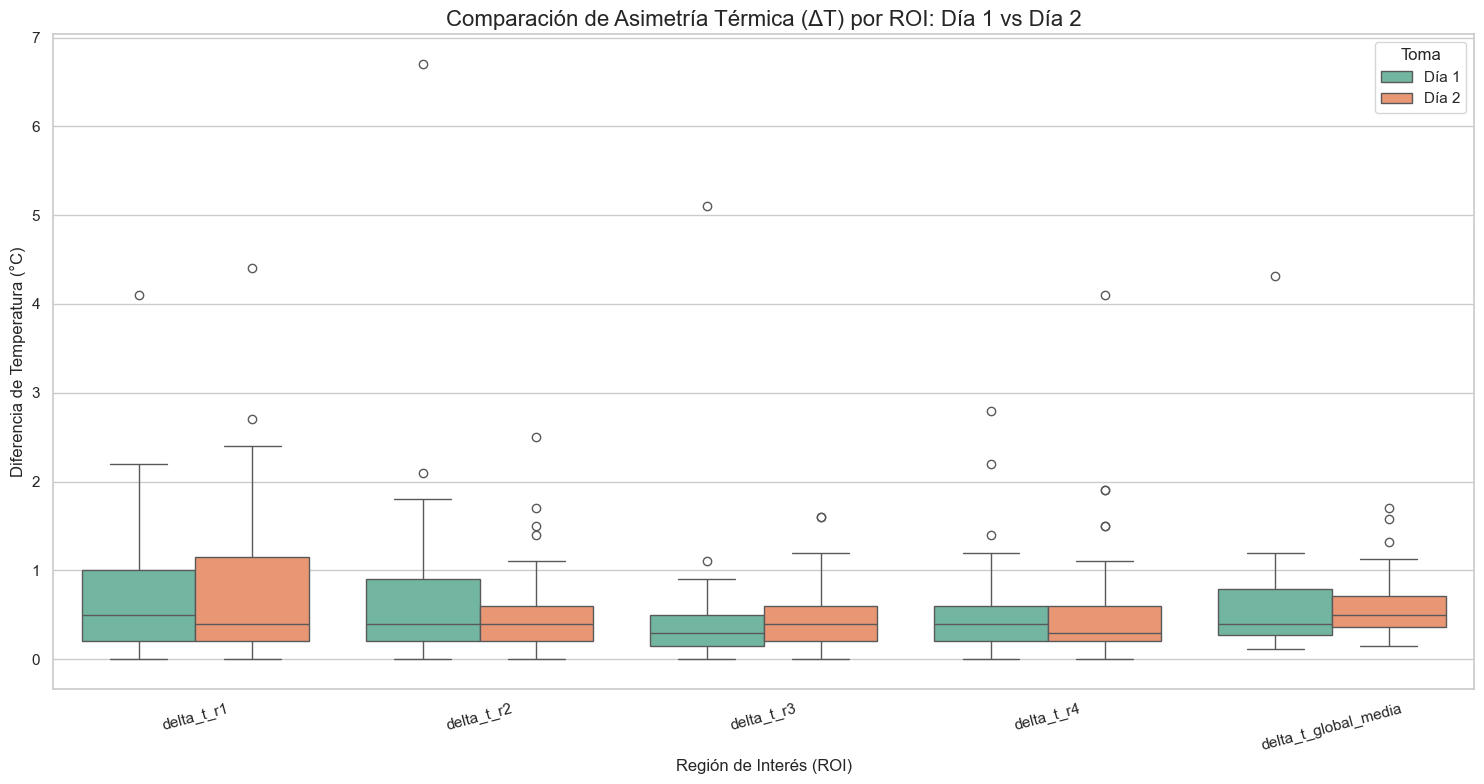

### RESULTADOS ESTADÍSTICOS CON TAMAÑO DEL EFECTO ###
delta_t_r1           | P-Value: 0.2203 | Tamaño Efecto (r): 0.253
delta_t_r2           | P-Value: 0.7307 | Tamaño Efecto (r): 0.104
delta_t_r3           | P-Value: 0.1692 | Tamaño Efecto (r): 0.314
delta_t_r4           | P-Value: 0.9946 | Tamaño Efecto (r): 0.134
delta_t_global_media | P-Value: 0.1829 | Tamaño Efecto (r): 0.271


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# # 1. CARGA Y PREPARACIÓN (Mismo proceso anterior)
# df1 = pd.read_csv('primeras_fotos.csv')
# df2 = pd.read_csv('segundas_fotos.csv')

comunes = set(df1['cedula']).intersection(set(df2['cedula']))
df1_pares = df1[df1['cedula'].isin(comunes)].sort_values('cedula').copy()
df2_pares = df2[df2['cedula'].isin(comunes)].sort_values('cedula').copy()

# Añadimos una columna de etiqueta para el gráfico
df1_pares['Momento'] = 'Día 1'
df2_pares['Momento'] = 'Día 2'

# Combinamos ambos dataframes para facilitar la graficación
df_long = pd.concat([df1_pares, df2_pares])

# ROIs a graficar
rois = ['delta_t_r1', 'delta_t_r2', 'delta_t_r3', 'delta_t_r4', 'delta_t_global_media']

# -------------------------------------------------------------------
# 2. GENERACIÓN DE GRÁFICOS (Boxplots)
# -------------------------------------------------------------------
plt.figure(figsize=(15, 8))

# Creamos un "Melt" para que Seaborn pueda entender las múltiples ROIs
df_plot = df_long.melt(id_vars=['Momento'], value_vars=rois,
                       var_name='ROI', value_name='Temperatura (°C)')

sns.set_theme(style="whitegrid")
ax = sns.boxplot(x='ROI', y='Temperatura (°C)', hue='Momento',
                 data=df_plot, palette="Set2")

plt.title('Comparación de Asimetría Térmica (ΔT) por ROI: Día 1 vs Día 2', fontsize=16)
plt.ylabel('Diferencia de Temperatura (°C)')
plt.xlabel('Región de Interés (ROI)')
plt.xticks(rotation=15)
plt.legend(title='Toma')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3. CÁLCULO ESTADÍSTICO (Con r de efecto)
# -------------------------------------------------------------------
def calcular_r(stat, n):
    return abs(1 - (4 * stat) / (n * (n + 1)))

print("### RESULTADOS ESTADÍSTICOS CON TAMAÑO DEL EFECTO ###")
for roi in rois:
    stat, p = wilcoxon(df1_pares[roi], df2_pares[roi])
    r = calcular_r(stat, len(df1_pares))
    print(f"{roi:20} | P-Value: {p:.4f} | Tamaño Efecto (r): {r:.3f}")

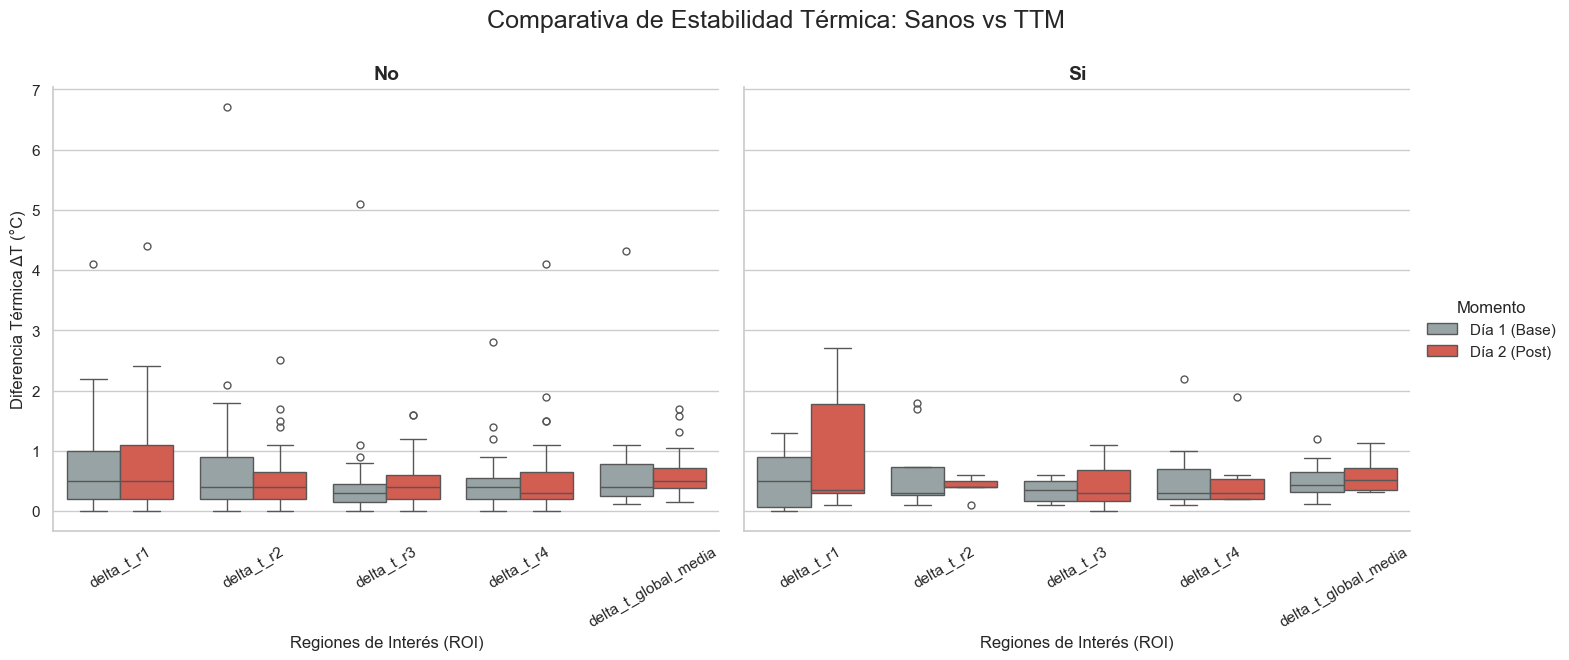

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARACIÓN DE DATOS (Asegurando limpieza de etiquetas)
df1_pares = df1.copy()
df2_pares = df2.copy()
# Suponiendo que df1_pares y df2_pares ya están definidos y filtrados
df1_pares['Momento'] = 'Día 1 (Base)'
df2_pares['Momento'] = 'Día 2 (Post)'

# Estandarizar la columna de diagnóstico
for df in [df1_pares, df2_pares]:
    df['Grupo'] = df['diagnosticado con ttm'].replace({
        0: 'Sanos (Control)',
        1: 'Pacientes TTM',
        '0': 'Sanos (Control)',
        '1': 'Pacientes TTM'
    })

# Combinar para graficar
df_long = pd.concat([df1_pares, df2_pares])
rois = ['delta_t_r1', 'delta_t_r2', 'delta_t_r3', 'delta_t_r4', 'delta_t_global_media']

# "Derretir" el dataframe para Seaborn
df_plot = df_long.melt(id_vars=['Momento', 'Grupo'], value_vars=rois,
                       var_name='ROI', value_name='Asimetría ΔT (°C)')

# 2. GENERACIÓN DEL GRÁFICO EN PANELES (FacetGrid)
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted")

g = sns.catplot(
    data=df_plot, x='ROI', y='Asimetría ΔT (°C)', hue='Momento',
    col='Grupo', kind='box', height=6, aspect=1.2,
    sharey=True, # Mantiene la misma escala en ambos para comparar real
    palette={'Día 1 (Base)': '#95a5a6', 'Día 2 (Post)': '#e74c3c'}
)

# Ajustes estéticos
g.set_titles("{col_name}", size=14, weight='bold')
g.set_xticklabels(rotation=30)
g.set_axis_labels("Regiones de Interés (ROI)", "Diferencia Térmica ΔT (°C)")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Comparativa de Estabilidad Térmica: Sanos vs TTM', fontsize=18)

plt.show()

In [91]:
df2.columns


Index(['numero de muestra', 'nombre', 'cedula', 'sexo', 'ocupacion', 'edad',
       'temperatura ambiente', 'temperatura basal', 'diagnosticado con ttm',
       'imagen: temperatura maxima derecha',
       'imagen: temperatura minima derecha',
       'imagen: temperatura media derecha', 'p1 derecha', 'p2 derecha',
       'r2: temperatura maxima derecha', 'r2: temperatura minima derecha',
       'r2: temperatura media derecha', 'r3: temperatura maxima derecha',
       'r3: temperatura minima derecha', 'r3: temperatura media derecha',
       'r4: temperatura maxima derecha', 'r4: temperatura minima derecha',
       'r4: temperatura media derecha', 'r1: temperatura maxima derecha',
       'r1: temperatura minima derecha', 'r1: temperatura media derecha',
       'imagen: temperatura maxima izquierda',
       'imagen: temperatura minima izquierda',
       'imagen: temperatura media izquierda', 'p1 izquierda', 'p2 izquierda',
       'r2: temperatura maxima izquierda', 'r2: temperatura minima

In [92]:
df5 = pd.read_csv('Link para recoleccion del instrumento #5 (Respuestas) - Respuestas de formulario 1.csv')
df5.columns

Index(['Column 67', 'Marca temporal', 'Fecha', 'Nombre', 'Apellido', 'Edad',
       'Sexo', 'Cédula ', 'Temperatura corporal (en grados celsius)',
       'ATM ANTERIOR DERECHA [Dolor]', 'ATM ANTERIOR DERECHA [No ]',
       'ATM ANTERIOR IZQUIERDA [Dolor]', 'ATM ANTERIOR IZQUIERDA [No ]',
       'ATM POSTERIOR DERECHA [Dolor]', 'ATM POSTERIOR DERECHA [Si]',
       'ATM POSTERIOR IZQUIERDA [Dolor SI]', 'ATM POSTERIOR IZQUIERDA [No ]',
       'Click', 'Salto', 'Crepitacion', 'Arenilla',
       'ESTERNOCLEIDOMASTOIDEO DERECHA [Dolor]',
       'ESTERNOCLEIDOMASTOIDEO DERECHA [Si ]',
       'ESTERNOCLEIDOMASTOIDEO DERECHA [No ]',
       'ESTERNOCLEIDOMASTOIDEO IZQUIERDA [Dolor]',
       'ESTERNOCLEIDOMASTOIDEO IZQUIERDA [Si ]',
       'ESTERNOCLEIDOMASTOIDEO IZQUIERDA [No ]', 'DIGASTRICO DERECHO [Dolor]',
       'DIGASTRICO DERECHO [Si ]', 'DIGASTRICO DERECHO [No ]',
       'DIGASTRICO IZQUIERDO [Dolor]', 'DIGASTRICO IZQUIERDO [Si ]',
       'DIGASTRICO IZQUIERDO [No ]', 'TEMPORAL DERECHO [D

In [100]:
df6 = pd.read_csv('../datos/respuestas_formulario_extendido.csv')
df7 = pd.read_csv('../datos/datos_termografia_procesados_segundas_fotos.csv')

In [101]:
list(df7.columns)

['numero de muestra',
 'nombre',
 'cedula',
 'sexo',
 'ocupacion',
 'edad',
 'temperatura ambiente',
 'temperatura basal',
 'diagnosticado con ttm',
 'imagen: temperatura maxima derecha',
 'imagen: temperatura minima derecha',
 'imagen: temperatura media derecha',
 'p1 derecha',
 'p2 derecha',
 'p3 derecha',
 'p4 derecha',
 'p5 derecha',
 'p6 derecha',
 'r2: temperatura maxima derecha',
 'r2: temperatura minima derecha',
 'r2: temperatura media derecha',
 'r3: temperatura maxima derecha',
 'r3: temperatura minima derecha',
 'r3: temperatura media derecha',
 'r4: temperatura maxima derecha',
 'r4: temperatura minima derecha',
 'r4: temperatura media derecha',
 'r1: temperatura maxima derecha',
 'r1: temperatura minima derecha',
 'r1: temperatura media derecha',
 'imagen: temperatura maxima izquierda',
 'imagen: temperatura minima izquierda',
 'imagen: temperatura media izquierda',
 'p1 izquierda',
 'p2 izquierda',
 'p3 izquierda',
 'p4 izquierda',
 'p5 izquierda',
 'p6 izquierda',
 'r2:

In [109]:

columnas = ['numero de muestra', 'cedula', 'edad',]

df1[columnas] = df1[columnas].astype('Int64')
df1.to_csv('datos_termografia_procesados_primeras_fotos.csv')

In [108]:
columnas = [
 'ATM_ANTERIOR_DERECHA_R3P1',
 'ATM_ANTERIOR_DERECHA_R3P2',
 'ATM_ANTERIOR_DERECHA_R3P3',
 'ATM_ANTERIOR_DERECHA_R3P6',
 'ATM_ANTERIOR_IZQUIERDA_R3P1',
 'ATM_ANTERIOR_IZQUIERDA_R3P2',
 'ATM_ANTERIOR_IZQUIERDA_R3P3',
 'ATM_POSTERIOR_DERECHA_R3P1',
 'ATM_POSTERIOR_DERECHA_R3P2',
 'ATM_POSTERIOR_DERECHA_R3P3',
 'ATM_POSTERIOR_IZQUIERDA_R3P1',
 'ATM_POSTERIOR_IZQUIERDA_R3P2',
 'ATM_POSTERIOR_IZQUIERDA_R3P3',
 'ATM_POSTERIOR_IZQUIERDA_R3P4',
 'ESTERNOCLEIDOMASTOIDEO_DERECHA_R2P2',
 'ESTERNOCLEIDOMASTOIDEO_DERECHA_R2P3',
 'ESTERNOCLEIDOMASTOIDEO_DERECHA_R2P4',
 'ESTERNOCLEIDOMASTOIDEO_DERECHA_R2P5',
 'ESTERNOCLEIDOMASTOIDEO_IZQUIERDA_R2P1',
 'ESTERNOCLEIDOMASTOIDEO_IZQUIERDA_R2P4',
 'ESTERNOCLEIDOMASTOIDEO_IZQUIERDA_R2P6',
 'ESTERNOCLEIDOMASTOIDEO_IZQUIERDA_R2P7',
 'MASETERO_DERECHO_R2P1',
 'MASETERO_DERECHO_R2P2',
 'MASETERO_DERECHO_R3P1',
 'MASETERO_DERECHO_R3P2',
 'MASETERO_DERECHO_R3P3',
 'MASETERO_DERECHO_R3P4',
 'MASETERO_DERECHO_R4P1',
 'MASETERO_DERECHO_R4P2',
 'MASETERO_DERECHO_R4P3',
 'MASETERO_DERECHO_R4P4',
 'MASETERO_IZQUIERDO_R2P3',
 'MASETERO_IZQUIERDO_R2P4',
 'MASETERO_IZQUIERDO_R3P1',
 'MASETERO_IZQUIERDO_R3P2',
 'MASETERO_IZQUIERDO_R3P3',
 'MASETERO_IZQUIERDO_R3P4',
 'MASETERO_IZQUIERDO_R3P5',
 'MASETERO_IZQUIERDO_R3P6',
 'MASETERO_IZQUIERDO_R4P1',
 'MASETERO_IZQUIERDO_R4P2',
 'MASETERO_IZQUIERDO_R4P3',
 'MASETERO_IZQUIERDO_R4P4',
 'MASETERO_IZQUIERDO_R4P5',
 'TEMPORAL_DERECHO_R1P1',
 'TEMPORAL_DERECHO_R1P2',
 'TEMPORAL_DERECHO_R1P7',
 'TEMPORAL_IZQUIERDO_R1P1',
 'TEMPORAL_IZQUIERDO_R1P2',
 'TEMPORAL_IZQUIERDO_R1P3']
df7.rename(columns={col: col.lower() for col in columnas}, inplace=True)
df7.columns
df7.to_csv('datos_termografia_procesados_segundas_fotos.csv')

In [107]:
df7

,numero de muestra,nombre,cedula,sexo,ocupacion,edad,temperatura ambiente,temperatura basal,diagnosticado con ttm,imagen: temperatura maxima derecha,...,masetero_izquierdo_r4p2,masetero_izquierdo_r4p3,masetero_izquierdo_r4p4,masetero_izquierdo_r4p5,temporal_derecho_r1p1,temporal_derecho_r1p2,temporal_derecho_r1p7,temporal_izquierdo_r1p1,temporal_izquierdo_r1p2,temporal_izquierdo_r1p3
0,1,JadassaPérez,30700340,Femenino,Estudiante,20,20.3,36.5,No,34.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2,AtilioBaptista,9014891,Masculino,Barbero,68,20.3,36.8,No,34.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3,AdrianFlores,29557033,Masculino,Estudiante,23,20.3,37.4,No,33.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,4,ValeriaLiendo,26952833,Femenino,Estudiante,26,20.3,36.5,No,34.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5,EdixonRincon,13609569,Masculino,Militar,47,20.3,36.5,Si,34.4,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,6,LigiaNaranjo,10496095,Femenino,osturera,55,20.3,36.3,No,34.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6,7,RosauraSanabria,3721720,Femenino,Amadeasa,78,20.3,36.5,No,34.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
7,8,GreydelaPeña,24524633,Femenino,Delhogar,60,20.3,36.5,No,34.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5
8,9,Gabrielabrera,30145371,Masculino,Freelancer,24,20.3,36.8,No,34.3,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,10,YajairaAlvarez,4074373,Femenino,Profesorauniversitaria,74,20.3,36.3,No,32.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7,7,<NA>,<NA>


In [106]:
df_filtered = df7.filter(like='p1')
df_filtered

,p1 derecha,p1 izquierda,atm_anterior_derecha_r3p1,atm_anterior_izquierda_r3p1,atm_posterior_derecha_r3p1,atm_posterior_izquierda_r3p1,esternocleidomastoideo_izquierda_r2p1,masetero_derecho_r2p1,masetero_derecho_r3p1,masetero_derecho_r4p1,masetero_izquierdo_r3p1,masetero_izquierdo_r4p1,temporal_derecho_r1p1,temporal_izquierdo_r1p1
0,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,32.5,32.1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,1,<NA>,<NA>
2,31.7,31.5,<NA>,<NA>,<NA>,<NA>,5,<NA>,<NA>,3,<NA>,<NA>,<NA>,<NA>
3,30.8,32.4,<NA>,<NA>,<NA>,<NA>,6,<NA>,7,<NA>,<NA>,<NA>,<NA>,<NA>
4,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,30.4,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>,<NA>,<NA>,<NA>,<NA>
6,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
7,30.7,33.2,<NA>,<NA>,<NA>,5,<NA>,<NA>,8,<NA>,<NA>,<NA>,<NA>,<NA>
8,30.6,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>
9,29.9,30.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9,<NA>,<NA>,<NA>,<NA>,7


In [97]:
list1 = list(df6.columns)
list2 = list(df7.columns)

not_present = [x for x in list1 if x not in list2]

print(not_present)

['Marca temporal', 'Fecha', 'Nombre', 'Apellido', 'Edad', 'Sexo', 'Cédula ']


In [99]:
list1 = list(df6.columns)
list2 = list(df7.columns)

not_present = [x for x in list2 if x not in list1]

print(not_present)

['nombre', 'cedula', 'sexo', 'ocupacion', 'edad', 'temperatura ambiente', 'diagnosticado con ttm', 'imagen: temperatura maxima derecha', 'imagen: temperatura minima derecha', 'imagen: temperatura media derecha', 'p1 derecha', 'p2 derecha', 'p3 derecha', 'p4 derecha', 'p5 derecha', 'p6 derecha', 'r2: temperatura maxima derecha', 'r2: temperatura minima derecha', 'r2: temperatura media derecha', 'r3: temperatura maxima derecha', 'r3: temperatura minima derecha', 'r3: temperatura media derecha', 'r4: temperatura maxima derecha', 'r4: temperatura minima derecha', 'r4: temperatura media derecha', 'r1: temperatura maxima derecha', 'r1: temperatura minima derecha', 'r1: temperatura media derecha', 'imagen: temperatura maxima izquierda', 'imagen: temperatura minima izquierda', 'imagen: temperatura media izquierda', 'p1 izquierda', 'p2 izquierda', 'p3 izquierda', 'p4 izquierda', 'p5 izquierda', 'p6 izquierda', 'r2: temperatura maxima izquierda', 'r2: temperatura minima izquierda', 'r2: temperat

In [9]:
df_final = pd.read_csv('/Users/micra/Dataland/Estudio_Termografia_y_Trastornos_Temporomandibulares/datos/datos_finales_termografia_procesados_todas_fotos.csv')

df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Columns: 195 entries, numero de muestra to temp_punto__temporal_izquierdo_r1p3
dtypes: float64(137), int64(54), str(4)
memory usage: 65.6 KB


<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 58 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   numero de muestra                     43 non-null     int64  
 1   nombre                                43 non-null     str    
 2   cedula                                43 non-null     int64  
 3   sexo                                  43 non-null     str    
 4   ocupacion                             43 non-null     str    
 5   edad                                  43 non-null     int64  
 6   temperatura ambiente                  43 non-null     float64
 7   temperatura basal                     43 non-null     float64
 8   diagnosticado con ttm                 43 non-null     str    
 9   imagen: temperatura maxima derecha    43 non-null     float64
 10  imagen: temperatura minima derecha    43 non-null     float64
 11  imagen: temperatura media derech

Total de personas con al menos un punto de dolor: 26 de 43 (60.5%)


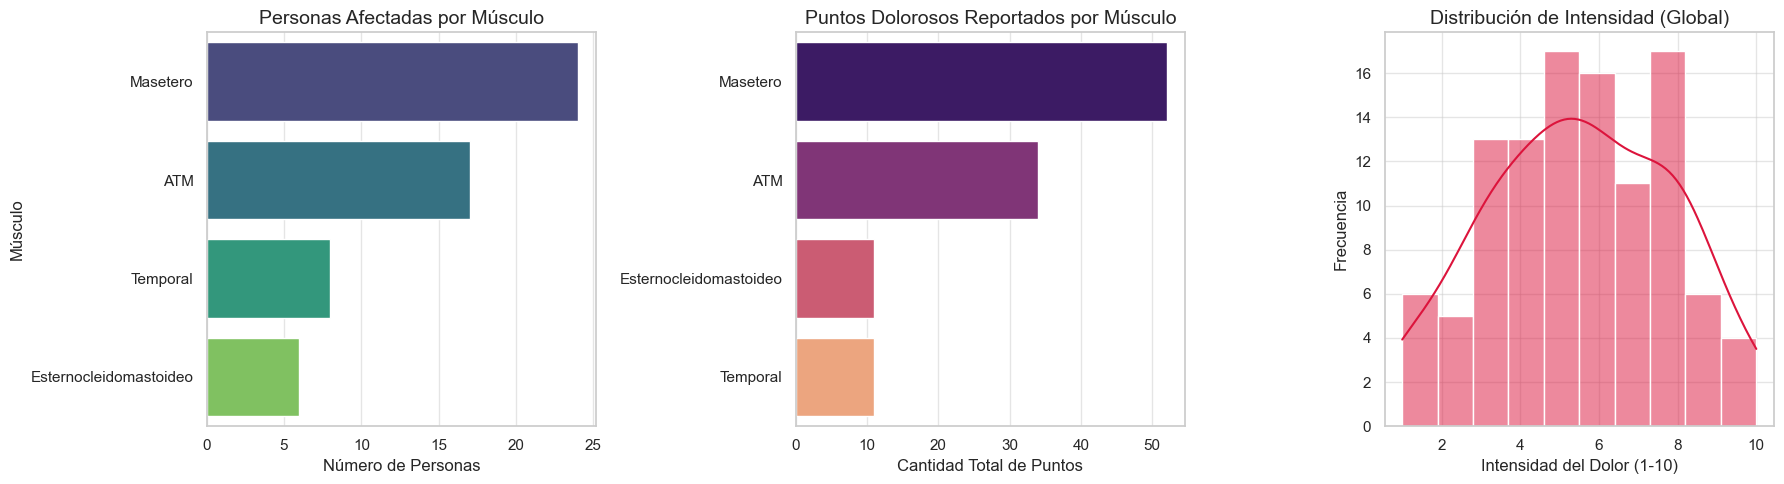

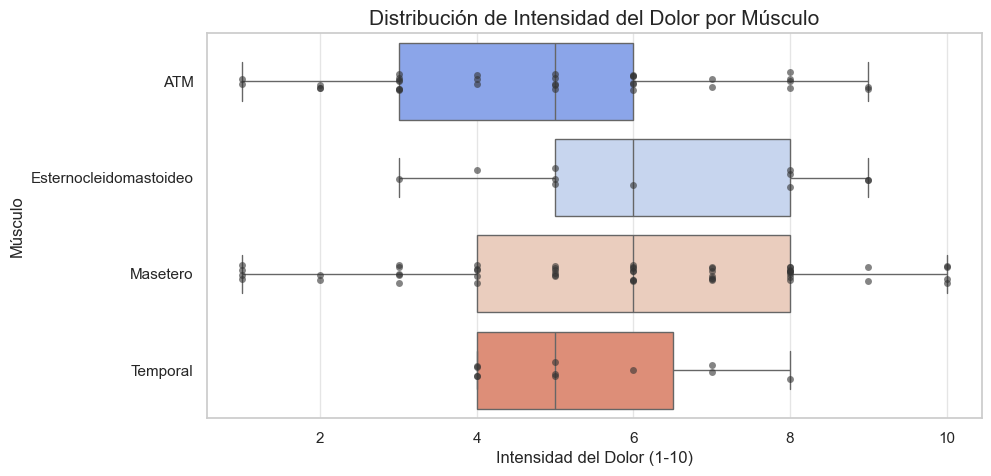

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset as requested
df_final = pd.read_csv('/Users/micra/Dataland/Estudio_Termografia_y_Trastornos_Temporomandibulares/datos/datos_finales_termografia_procesados_todas_fotos.csv')

# Identificar columnas correspondientes a los puntos de palpación (dolor)
# Excluimos 'temp_punto' para no mezclar con las columnas de temperatura
columnas_dolor = [col for col in df_final.columns if any(musculo in col for musculo in ['atm_', 'masetero_', 'temporal_', 'esternocleidomastoideo_']) and 'temp_punto' not in col]

# Transformar el dataframe a formato largo (long format) para facilitar el análisis
df_dolor = df_final.melt(id_vars=['numero de muestra', 'nombre'], 
                         value_vars=columnas_dolor, 
                         var_name='punto_muscular', 
                         value_name='intensidad_dolor')

# Filtrar valores nulos y ceros (nos quedamos solo con reportes reales de dolor > 0)
df_dolor = df_dolor.dropna(subset=['intensidad_dolor'])
df_dolor['intensidad_dolor'] = pd.to_numeric(df_dolor['intensidad_dolor'], errors='coerce')
df_dolor = df_dolor[df_dolor['intensidad_dolor'] > 0]

# Función para agrupar los puntos específicos en los músculos/regiones principales
def extraer_musculo(nombre_col):
    if 'atm' in nombre_col: return 'ATM'
    if 'masetero' in nombre_col: return 'Masetero'
    if 'temporal' in nombre_col: return 'Temporal'
    if 'esternocleidomastoideo' in nombre_col: return 'Esternocleidomastoideo'
    return 'Otro'

df_dolor['musculo'] = df_dolor['punto_muscular'].apply(extraer_musculo)

# 1. Resumen general de personas afectadas
personas_afectadas = df_dolor['numero de muestra'].nunique()
total_personas = df_final['numero de muestra'].nunique()
print(f"Total de personas con al menos un punto de dolor: {personas_afectadas} de {total_personas} ({(personas_afectadas/total_personas)*100:.1f}%)")

# 2. Configuración de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 2.1: Personas afectadas por músculo (conteo de pacientes únicos)
personas_por_musculo = df_dolor.groupby('musculo')['numero de muestra'].nunique().sort_values(ascending=False)
sns.barplot(x=personas_por_musculo.values, y=personas_por_musculo.index, ax=axes[0], palette="viridis", hue=personas_por_musculo.index, legend=False)
axes[0].set_title('Personas Afectadas por Músculo', fontsize=14)
axes[0].set_xlabel('Número de Personas')
axes[0].set_ylabel('Músculo')

# Gráfico 2.2: Frecuencia de puntos dolorosos por músculo (total de reportes)
conteo_musculos = df_dolor['musculo'].value_counts()
sns.barplot(x=conteo_musculos.values, y=conteo_musculos.index, ax=axes[1], palette="magma", hue=conteo_musculos.index, legend=False)
axes[1].set_title('Puntos Dolorosos Reportados por Músculo', fontsize=14)
axes[1].set_xlabel('Cantidad Total de Puntos')
axes[1].set_ylabel('')

# Gráfico 2.3: Distribución de la Intensidad del Dolor
sns.histplot(data=df_dolor, x='intensidad_dolor', bins=10, kde=True, ax=axes[2], color='crimson')
axes[2].set_title('Distribución de Intensidad (Global)', fontsize=14)
axes[2].set_xlabel('Intensidad del Dolor (1-10)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 3. Gráfico adicional: Boxplot de intensidad de dolor detallado por músculo
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_dolor, x='intensidad_dolor', y='musculo', palette="coolwarm", hue='musculo', legend=False, showfliers=False)
sns.stripplot(data=df_dolor, x='intensidad_dolor', y='musculo', color=".2", alpha=0.6, size=5, jitter=True)
plt.title('Distribución de Intensidad del Dolor por Músculo', fontsize=15)
plt.xlabel('Intensidad del Dolor (1-10)', fontsize=12)
plt.ylabel('Músculo', fontsize=12)
plt.show()



In [16]:
# Generar tabla numérica con la información de los puntos de dolor
import pandas as pd

# Agrupar los datos para calcular métricas por músculo
tabla_resumen = df_dolor.groupby('musculo').agg(
    Puntos_Dolorosos_Reportados=('punto_muscular', 'count'),
    Pacientes_Afectados=('numero de muestra', 'nunique'),
    Intensidad_Media=('intensidad_dolor', 'mean'),
    Intensidad_Mediana=('intensidad_dolor', 'median'),
    Intensidad_Min=('intensidad_dolor', 'min'),
    Intensidad_Max=('intensidad_dolor', 'max')
).reset_index()

# Redondear la intensidad media para mejor visualización
tabla_resumen['Intensidad_Media'] = tabla_resumen['Intensidad_Media'].round(2)

# Ordenar por el número de puntos dolorosos reportados
tabla_resumen = tabla_resumen.sort_values('Puntos_Dolorosos_Reportados', ascending=False).reset_index(drop=True)

# Calcular totales globales para añadir una fila de "Total/Global"
total_puntos = tabla_resumen['Puntos_Dolorosos_Reportados'].sum()
total_pacientes_unicos = df_dolor['numero de muestra'].nunique() # Pacientes únicos en total (no la suma por músculo)
media_global = round(df_dolor['intensidad_dolor'].mean(), 2)
mediana_global = df_dolor['intensidad_dolor'].median()
min_global = df_dolor['intensidad_dolor'].min()
max_global = df_dolor['intensidad_dolor'].max()

fila_total = pd.DataFrame({
    'musculo': ['TOTAL / GLOBAL'],
    'Puntos_Dolorosos_Reportados': [total_puntos],
    'Pacientes_Afectados': [total_pacientes_unicos],
    'Intensidad_Media': [media_global],
    'Intensidad_Mediana': [mediana_global],
    'Intensidad_Min': [min_global],
    'Intensidad_Max': [max_global]
})

tabla_final = pd.concat([tabla_resumen, fila_total], ignore_index=True)

# Mostrar la tabla
display(tabla_final)


,musculo,Puntos_Dolorosos_Reportados,Pacientes_Afectados,Intensidad_Media,Intensidad_Mediana,Intensidad_Min,Intensidad_Max
0,Masetero,52,24,5.77,6.0,1,10
1,ATM,34,17,4.88,5.0,1,9
2,Esternocleidomastoideo,11,6,6.36,6.0,3,9
3,Temporal,11,8,5.36,5.0,4,8
4,TOTAL / GLOBAL,108,26,5.51,5.5,1,10


In [17]:
tabla_final

,musculo,Puntos_Dolorosos_Reportados,Pacientes_Afectados,Intensidad_Media,Intensidad_Mediana,Intensidad_Min,Intensidad_Max
0,Masetero,52,24,5.77,6.0,1,10
1,ATM,34,17,4.88,5.0,1,9
2,Esternocleidomastoideo,11,6,6.36,6.0,3,9
3,Temporal,11,8,5.36,5.0,4,8
4,TOTAL / GLOBAL,108,26,5.51,5.5,1,10


In [19]:
# Generar estadísticas básicas de Sexo, Edad y Temperatura Basal
import pandas as pd
from IPython.display import display

# Cargar los datos
df_stats = pd.read_csv('/Users/micra/Dataland/Estudio_Termografia_y_Trastornos_Temporomandibulares/datos/datos_finales_termografia_procesados_todas_fotos.csv')

# Asegurarnos de tener un registro único por paciente para estadísticas demográficas
if 'numero de muestra' in df_stats.columns:
    df_stats = df_stats.drop_duplicates(subset=['numero de muestra'])

print("--- ESTADÍSTICAS BÁSICAS ---")
print("\n1. Distribución por Sexo:")
sexo_stats = df_stats['sexo'].value_counts().to_frame(name='Cantidad')
sexo_stats['Porcentaje (%)'] = (df_stats['sexo'].value_counts(normalize=True) * 100).round(2)
display(sexo_stats)

print("\n2. Estadísticas de Edad y Temperatura Basal:")
# Asegurar que sean numéricas
df_stats['edad'] = pd.to_numeric(df_stats['edad'], errors='coerce')
df_stats['temperatura basal_primera'] = pd.to_numeric(df_stats['temperatura basal_primera'], errors='coerce')

num_stats = df_stats[['edad', 'temperatura basal_primera']].describe().T
num_stats = num_stats[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)
num_stats.columns = ['Cantidad', 'Media', 'Desv. Est.', 'Mínimo', 'Mediana', 'Máximo']
display(num_stats)


--- ESTADÍSTICAS BÁSICAS ---

1. Distribución por Sexo:


,Cantidad,Porcentaje (%)
sexo,,
Femenino,29,67.44
Masculino,14,32.56



2. Estadísticas de Edad y Temperatura Basal:


,Cantidad,Media,Desv. Est.,Mínimo,Mediana,Máximo
edad,43.0,36.00,16.90,18.0,27.0,78.0
temperatura basal_primera,43.0,36.57,0.26,36.2,36.5,37.4


In [20]:
num_stats

,Cantidad,Media,Desv. Est.,Mínimo,Mediana,Máximo
edad,43.0,36.00,16.90,18.0,27.0,78.0
temperatura basal_primera,43.0,36.57,0.26,36.2,36.5,37.4
